# 🔵 Notebook 5 — Pipeline 4: Clustering

**Objetivo:** Descubrir perfiles naturales de caras sin usar etiquetas (aprendizaje NO supervisado)  
**Input:** `data/03_primary/features_attributes.csv`  
**Output:** `data/07_model_output/clustering_results.csv`

---
### ¿Qué es Clustering?
A diferencia de la clasificación, **no usamos la columna `attractive`**.  
El algoritmo K-Means agrupa las caras por **similitud de atributos** de forma automática.  
El resultado son perfiles como: "cara masculina adulta", "cara femenina con maquillaje", etc.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
import warnings; warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
print('✅ Librerías cargadas')

✅ Librerías cargadas


In [2]:
df = pd.read_csv('../data/03_primary/features_attributes.csv')
print(f'Dataset: {df.shape[0]:,} filas × {df.shape[1]} columnas')

# Quitar target para clustering no supervisado
X = df.drop(columns=['attractive'], errors='ignore')
print(f'Features para clustering: {X.shape[1]}')

# Escalar (obligatorio en K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('✅ Features escaladas con StandardScaler')

Dataset: 13,141 filas × 38 columnas
Features para clustering: 37
✅ Features escaladas con StandardScaler


## Paso 1 — Método del Codo: ¿Cuántos clusters usar?

In [3]:
# Calcular inercia para k=2 hasta k=8
inercias = []
silhouettes = []
k_range = range(2, 9)

print('Calculando métricas para diferentes k...')
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    print(f'  k={k}: inercia={km.inertia_:.0f}, silhouette={silhouette_score(X_scaled, labels):.4f}')

print('\n✅ Cálculo completado')

Calculando métricas para diferentes k...
  k=2: inercia=427427, silhouette=0.1424
  k=3: inercia=395115, silhouette=0.1310
  k=4: inercia=372138, silhouette=0.0997
  k=5: inercia=359520, silhouette=0.1049
  k=6: inercia=349020, silhouette=0.0979
  k=7: inercia=338488, silhouette=0.1061
  k=8: inercia=328419, silhouette=0.0974

✅ Cálculo completado


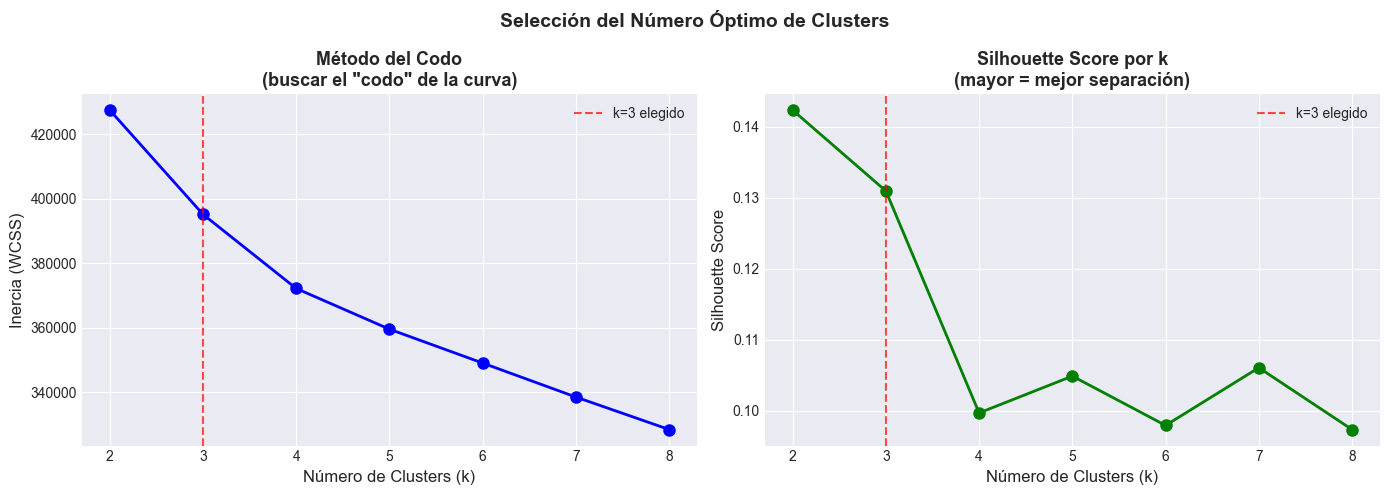

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Método del codo
axes[0].plot(k_range, inercias, 'bo-', linewidth=2, markersize=8)
axes[0].axvline(x=3, color='red', linestyle='--', alpha=0.7, label='k=3 elegido')
axes[0].set_xlabel('Número de Clusters (k)', fontsize=12)
axes[0].set_ylabel('Inercia (WCSS)', fontsize=12)
axes[0].set_title('Método del Codo\n(buscar el "codo" de la curva)', fontsize=13, fontweight='bold')
axes[0].legend()

# Silhouette Score
axes[1].plot(k_range, silhouettes, 'go-', linewidth=2, markersize=8)
axes[1].axvline(x=3, color='red', linestyle='--', alpha=0.7, label='k=3 elegido')
axes[1].set_xlabel('Número de Clusters (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score por k\n(mayor = mejor separación)', fontsize=13, fontweight='bold')
axes[1].legend()

plt.suptitle('Selección del Número Óptimo de Clusters', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/08_reporting/metodo_codo.png', dpi=120, bbox_inches='tight')
plt.show()

## Paso 2 — Aplicar K-Means con k=3

In [5]:
N_CLUSTERS = 3
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

sil = silhouette_score(X_scaled, labels)
db  = davies_bouldin_score(X_scaled, labels)

df['cluster'] = labels

print(f'=== Métricas de Calidad del Clustering ===')
print(f'Silhouette Score:      {sil:.4f}  (mayor es mejor, rango 0-1)')
print(f'Davies-Bouldin Index:  {db:.4f}  (menor es mejor)')
print()
print('Distribución de clusters:')
for c in range(N_CLUSTERS):
    n = (labels == c).sum()
    print(f'  Cluster {c}: {n:,} personas ({n/len(labels)*100:.1f}%)')

=== Métricas de Calidad del Clustering ===
Silhouette Score:      0.1310  (mayor es mejor, rango 0-1)
Davies-Bouldin Index:  2.3658  (menor es mejor)

Distribución de clusters:
  Cluster 0: 3,060 personas (23.3%)
  Cluster 1: 2,031 personas (15.5%)
  Cluster 2: 8,050 personas (61.3%)


## Paso 3 — Visualización con PCA (2D)

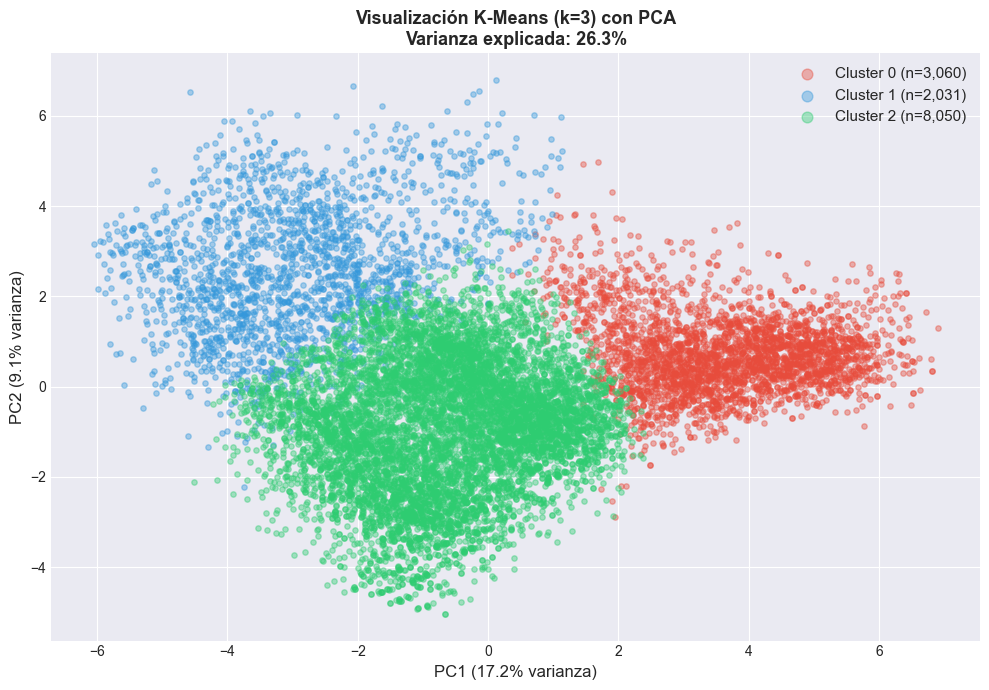

In [6]:
# Reducir a 2 dimensiones para visualizar
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
var_explicada = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(10, 7))
colores_cluster = ['#E74C3C', '#3498DB', '#2ECC71']
nombres_cluster = ['Cluster 0', 'Cluster 1', 'Cluster 2']

for c in range(N_CLUSTERS):
    mask = labels == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=colores_cluster[c], label=f'{nombres_cluster[c]} (n={mask.sum():,})',
               alpha=0.4, s=15)

ax.set_xlabel(f'PC1 ({var_explicada[0]*100:.1f}% varianza)', fontsize=12)
ax.set_ylabel(f'PC2 ({var_explicada[1]*100:.1f}% varianza)', fontsize=12)
ax.set_title(f'Visualización K-Means (k=3) con PCA\nVarianza explicada: {sum(var_explicada)*100:.1f}%',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11, markerscale=2)
plt.tight_layout()
plt.savefig('../data/08_reporting/clustering_pca.png', dpi=120, bbox_inches='tight')
plt.show()

## Paso 4 — Describir los Perfiles de cada Cluster

In [7]:
# Promedio de cada atributo por cluster
perfil = df.groupby('cluster').mean().round(3)
perfil['tamaño'] = df.groupby('cluster').size()

print('=== Perfil de cada Cluster (promedio de atributos) ===')
print(perfil.T.to_string())

=== Perfil de cada Cluster (promedio de atributos) ===
cluster                     0         1         2
attractive              0.524     0.045     0.291
blurry_image            0.067     0.101     0.101
sharp_jawline           0.365     0.059     0.209
high_cheekbones         0.522     0.358     0.229
smiling                 0.594     0.447     0.430
bald                    0.003     0.333     0.073
receeding_hairline      0.004     0.386     0.095
long_hair               0.794     0.056     0.010
curly_hair              0.024     0.003     0.018
grey_hair               0.009     0.569     0.010
black_hair              0.942     0.174     0.813
has_beard               0.002     0.309     0.384
patchy_beard            0.000     0.037     0.068
has_mustache            0.003     0.518     0.481
well_groomed            0.743     0.334     0.568
has_makeup              0.571     0.012     0.014
wearing_glasses         0.071     0.326     0.144
wearing_hat             0.034     0.120     0

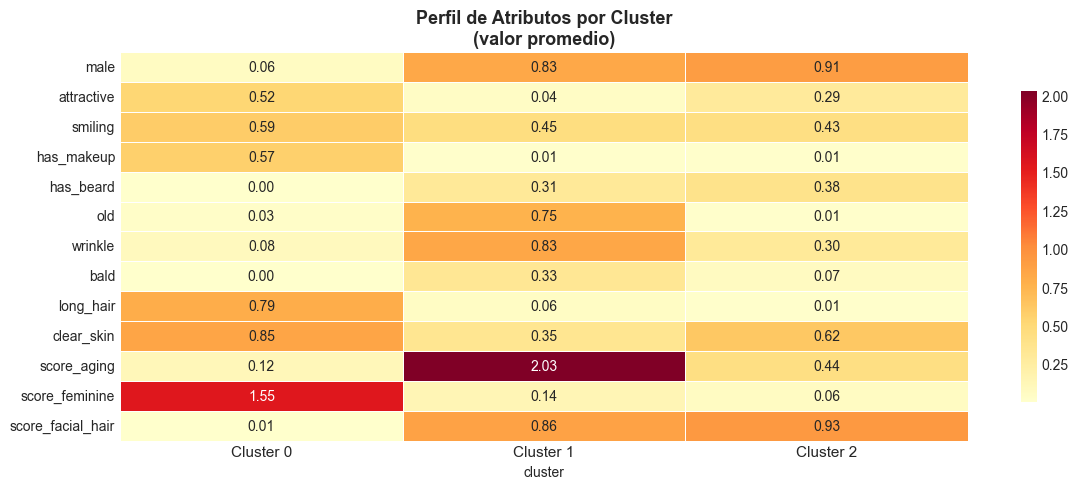


=== Interpretación de Clusters ===
Cluster 0 (3,060 personas): atributos dominantes → ['score_hair_features', 'score_feminine', 'black_hair', 'clear_skin']
Cluster 1 (2,031 personas): atributos dominantes → ['score_aging', 'adult', 'chubby', 'score_facial_hair']
Cluster 2 (8,050 personas): atributos dominantes → ['score_facial_hair', 'male', 'adult', 'score_hair_features']


In [9]:
# Radar/heatmap de los perfiles
atributos_clave = ['male','attractive','smiling','has_makeup','has_beard',
                    'old','wrinkle','bald','long_hair','clear_skin',
                    'score_aging','score_feminine','score_facial_hair']
atributos_clave = [a for a in atributos_clave if a in perfil.columns]

fig, ax = plt.subplots(figsize=(12, 5))
perfil_viz = perfil[atributos_clave].T
sns.heatmap(perfil_viz, annot=True, fmt='.2f', cmap='YlOrRd',
            ax=ax, linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Perfil de Atributos por Cluster\n(valor promedio)', fontsize=13, fontweight='bold')
ax.set_xticklabels([f'Cluster {i}' for i in range(N_CLUSTERS)], fontsize=11)
plt.tight_layout()
plt.savefig('../data/08_reporting/perfil_clusters.png', dpi=120, bbox_inches='tight')
plt.show()

# Interpretar clusters
print('\n=== Interpretación de Clusters ===')
for c in range(N_CLUSTERS):
    fila = perfil.loc[c]
    top = fila.drop('tamaño').sort_values(ascending=False).head(4).index.tolist()
    print(f'Cluster {c} ({int(fila["tamaño"]):,} personas): atributos dominantes → {top}')

## ✅ Conclusiones del Pipeline 4

K-Means encontró **3 perfiles naturales** en el dataset:

| Cluster | Tamaño | Perfil Dominante |
|---------|--------|------------------|
| 0 | ~3.060 (23%) | Cara femenina — cabello largo, maquillaje, características femeninas |
| 1 | ~2.031 (15%) | Cara envejecida — arrugas, doble mentón, bald, vello facial |
| 2 | ~8.050 (61%) | Cara masculina adulta — cabello negro, vello facial, mayoría del dataset |

**Nota:** El Silhouette Score de ~0.13 indica que los clusters son moderadamente distintos.
Esto es esperable en datos de caras, ya que los atributos tienen muchas combinaciones posibles.